In [ ]:
"""
Dissertation analysis code — Implied Volatility and Future U.S. Stock Returns
Sample: January 2004 – June 2026 | Indices: S&P 500/VIX, NASDAQ-100/VXN, Russell 2000/RVX
Software: Python 3, pandas, numpy, statsmodels, matplotlib.
"""

import os
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ---------------------------------------------------------------------------
# 0. Where the data files live
# ---------------------------------------------------------------------------
for cand in ["/content", "/mnt/user-data/uploads", "."]:
    if os.path.exists(os.path.join(cand, "VIX.xlsx")):
        DATA_DIR = cand
        break

# ---------------------------------------------------------------------------
# 1. Risk-free rate: FRED TB3MS (monthly, % p.a.)
#    3-Month Treasury Bill Secondary Market Rate [TB3MS], via FRED.
# ---------------------------------------------------------------------------
RF_TB3MS_FRED = """\
date,tb3ms
2003-12-01,0.90
2004-01-01,0.88
2004-02-01,0.93
2004-03-01,0.94
2004-04-01,0.94
2004-05-01,1.02
2004-06-01,1.27
2004-07-01,1.33
2004-08-01,1.48
2004-09-01,1.65
2004-10-01,1.76
2004-11-01,2.07
2004-12-01,2.19
2005-01-01,2.33
2005-02-01,2.54
2005-03-01,2.74
2005-04-01,2.78
2005-05-01,2.84
2005-06-01,2.97
2005-07-01,3.22
2005-08-01,3.44
2005-09-01,3.42
2005-10-01,3.71
2005-11-01,3.88
2005-12-01,3.89
2006-01-01,4.24
2006-02-01,4.43
2006-03-01,4.51
2006-04-01,4.60
2006-05-01,4.72
2006-06-01,4.79
2006-07-01,4.95
2006-08-01,4.96
2006-09-01,4.81
2006-10-01,4.92
2006-11-01,4.94
2006-12-01,4.85
2007-01-01,4.98
2007-02-01,5.03
2007-03-01,4.94
2007-04-01,4.87
2007-05-01,4.73
2007-06-01,4.61
2007-07-01,4.82
2007-08-01,4.20
2007-09-01,3.89
2007-10-01,3.90
2007-11-01,3.27
2007-12-01,3.00
2008-01-01,2.75
2008-02-01,2.12
2008-03-01,1.26
2008-04-01,1.29
2008-05-01,1.73
2008-06-01,1.86
2008-07-01,1.63
2008-08-01,1.72
2008-09-01,1.13
2008-10-01,0.67
2008-11-01,0.19
2008-12-01,0.03
2009-01-01,0.13
2009-02-01,0.30
2009-03-01,0.21
2009-04-01,0.16
2009-05-01,0.18
2009-06-01,0.18
2009-07-01,0.18
2009-08-01,0.17
2009-09-01,0.12
2009-10-01,0.07
2009-11-01,0.05
2009-12-01,0.05
2010-01-01,0.06
2010-02-01,0.11
2010-03-01,0.15
2010-04-01,0.16
2010-05-01,0.16
2010-06-01,0.12
2010-07-01,0.16
2010-08-01,0.16
2010-09-01,0.15
2010-10-01,0.13
2010-11-01,0.14
2010-12-01,0.14
2011-01-01,0.15
2011-02-01,0.13
2011-03-01,0.10
2011-04-01,0.06
2011-05-01,0.04
2011-06-01,0.04
2011-07-01,0.04
2011-08-01,0.02
2011-09-01,0.01
2011-10-01,0.02
2011-11-01,0.01
2011-12-01,0.01
2012-01-01,0.03
2012-02-01,0.09
2012-03-01,0.08
2012-04-01,0.08
2012-05-01,0.09
2012-06-01,0.09
2012-07-01,0.10
2012-08-01,0.10
2012-09-01,0.11
2012-10-01,0.10
2012-11-01,0.09
2012-12-01,0.07
2013-01-01,0.07
2013-02-01,0.10
2013-03-01,0.09
2013-04-01,0.06
2013-05-01,0.04
2013-06-01,0.05
2013-07-01,0.04
2013-08-01,0.04
2013-09-01,0.02
2013-10-01,0.05
2013-11-01,0.07
2013-12-01,0.07
2014-01-01,0.04
2014-02-01,0.05
2014-03-01,0.05
2014-04-01,0.03
2014-05-01,0.03
2014-06-01,0.04
2014-07-01,0.03
2014-08-01,0.03
2014-09-01,0.02
2014-10-01,0.02
2014-11-01,0.02
2014-12-01,0.03
2015-01-01,0.03
2015-02-01,0.02
2015-03-01,0.03
2015-04-01,0.02
2015-05-01,0.02
2015-06-01,0.02
2015-07-01,0.03
2015-08-01,0.07
2015-09-01,0.02
2015-10-01,0.02
2015-11-01,0.12
2015-12-01,0.23
2016-01-01,0.26
2016-02-01,0.31
2016-03-01,0.29
2016-04-01,0.23
2016-05-01,0.27
2016-06-01,0.27
2016-07-01,0.30
2016-08-01,0.30
2016-09-01,0.29
2016-10-01,0.33
2016-11-01,0.45
2016-12-01,0.51
2017-01-01,0.51
2017-02-01,0.52
2017-03-01,0.74
2017-04-01,0.80
2017-05-01,0.89
2017-06-01,0.98
2017-07-01,1.07
2017-08-01,1.01
2017-09-01,1.03
2017-10-01,1.07
2017-11-01,1.23
2017-12-01,1.32
2018-01-01,1.41
2018-02-01,1.57
2018-03-01,1.70
2018-04-01,1.76
2018-05-01,1.86
2018-06-01,1.90
2018-07-01,1.96
2018-08-01,2.03
2018-09-01,2.13
2018-10-01,2.25
2018-11-01,2.33
2018-12-01,2.37
2019-01-01,2.37
2019-02-01,2.39
2019-03-01,2.40
2019-04-01,2.38
2019-05-01,2.35
2019-06-01,2.17
2019-07-01,2.10
2019-08-01,1.95
2019-09-01,1.89
2019-10-01,1.65
2019-11-01,1.54
2019-12-01,1.54
2020-01-01,1.52
2020-02-01,1.52
2020-03-01,0.29
2020-04-01,0.14
2020-05-01,0.13
2020-06-01,0.16
2020-07-01,0.13
2020-08-01,0.10
2020-09-01,0.11
2020-10-01,0.10
2020-11-01,0.09
2020-12-01,0.09
2021-01-01,0.08
2021-02-01,0.04
2021-03-01,0.03
2021-04-01,0.02
2021-05-01,0.02
2021-06-01,0.04
2021-07-01,0.05
2021-08-01,0.05
2021-09-01,0.04
2021-10-01,0.05
2021-11-01,0.05
2021-12-01,0.06
2022-01-01,0.15
2022-02-01,0.33
2022-03-01,0.44
2022-04-01,0.76
2022-05-01,0.98
2022-06-01,1.49
2022-07-01,2.23
2022-08-01,2.63
2022-09-01,3.13
2022-10-01,3.72
2022-11-01,4.15
2022-12-01,4.25
2023-01-01,4.54
2023-02-01,4.65
2023-03-01,4.69
2023-04-01,4.92
2023-05-01,5.14
2023-06-01,5.16
2023-07-01,5.25
2023-08-01,5.30
2023-09-01,5.32
2023-10-01,5.34
2023-11-01,5.27
2023-12-01,5.24
2024-01-01,5.22
2024-02-01,5.24
2024-03-01,5.24
2024-04-01,5.24
2024-05-01,5.25
2024-06-01,5.24
2024-07-01,5.20
2024-08-01,5.05
2024-09-01,4.72
2024-10-01,4.51
2024-11-01,4.42
2024-12-01,4.27
2025-01-01,4.21
2025-02-01,4.22
2025-03-01,4.20
2025-04-01,4.21
2025-05-01,4.25
2025-06-01,4.23
2025-07-01,4.25
2025-08-01,4.12
2025-09-01,3.92
2025-10-01,3.82
2025-11-01,3.78
2025-12-01,3.59
2026-01-01,3.57
2026-02-01,3.60
2026-03-01,3.61
2026-04-01,3.61
2026-05-01,3.60
2026-06-01,3.66
2026-07-01,3.73
"""

try:
    rf = pd.read_csv("rf_tb3ms_fred.csv", parse_dates=["date"])   # use the file if present
except FileNotFoundError:
    rf = pd.read_csv(StringIO(RF_TB3MS_FRED), parse_dates=["date"])  # else the embedded series

# ---------------------------------------------------------------------------
# 2. Loading the daily Bloomberg exports.
#    Every file is two columns: a date column and PX_LAST (the daily close).
#    Two files (VXN.xlsx, nasdaq.xlsx) store dates as Excel serial numbers
#    (days since 30 Dec 1899), which the loader converts.
# ---------------------------------------------------------------------------
def load_std(fname, colname):
    df = pd.read_excel(os.path.join(DATA_DIR, fname))
    df = df.rename(columns={df.columns[0]: "date", df.columns[1]: colname})
    if pd.api.types.is_numeric_dtype(df["date"]):  # Excel serial dates
        df["date"] = pd.to_datetime("1899-12-30") + pd.to_timedelta(df["date"], unit="D")
    df["date"] = pd.to_datetime(df["date"])
    return (df.dropna(subset=["date", colname])
              .sort_values("date")
              .reset_index(drop=True)[["date", colname]])

prices = {                                   # index price levels (daily close)
    "sp500":   load_std("SP500-price.xlsx", "px"),
    "nasdaq":  load_std("nasdaq.xlsx", "px"),
    "russell": load_std("russel.xlsx", "px"),
}
iv = {                                       # implied volatility indices (daily close, % p.a.)
    "sp500":   load_std("VIX.xlsx", "iv"),
    "nasdaq":  load_std("VXN.xlsx", "iv"),
    "russell": load_std("RVX.xlsx", "iv"),
}
move = load_std("MOVE.xlsx", "move")         # bond-market implied vol (level)
gold = load_std("GOLD.xlsx", "gold")         # gold spot (level -> returns)
oil  = load_std("WTIOIL.xlsx", "oil")        # WTI crude (level -> returns)

# ---------------------------------------------------------------------------
# 3. Monthly construction.
#    month_end():   last available daily observation in each calendar month.
#    monthly_log_ret(): r_t = ln(P_t / P_{t-1}) using month-end levels.
#    realised_vol(): annualised RV for month t from daily log returns within
#    month t:  RV_t = 100 * sqrt( (252 / n_t) * sum(r_d^2) ),
#    which puts RV in the same units (% p.a.) as the implied vol indices.
# ---------------------------------------------------------------------------
def month_end(df, col):
    return df.set_index("date")[col].groupby(pd.Grouper(freq="ME")).last()

def monthly_log_ret(df, col):
    me = month_end(df, col)
    return np.log(me / me.shift(1))

def realised_vol(df, col):
    d = df.set_index("date")[col]
    r = np.log(d / d.shift(1))
    def rv(x):
        x = x.dropna()
        return np.nan if len(x) < 5 else 100 * np.sqrt(252.0 / len(x) * (x ** 2).sum())
    return r.groupby(pd.Grouper(freq="ME")).apply(rv)

ctrl = pd.DataFrame({
    "move":     month_end(move, "move"),
    "gold_ret": monthly_log_ret(gold, "gold"),
    "oil_ret":  monthly_log_ret(oil, "oil"),
    "tbill3m":  rf.set_index("date")["tb3ms"].resample("ME").last().ffill(limit=1),
})

# ---------------------------------------------------------------------------
# 4. Sample, alignment and crisis dummies.
#    - Sample starts Jan 2004 because the RVX begins 2 Jan 2004 (common
#      sample across all three pairs for comparability).
#    - Timing (no look-ahead): predictors measured at end of month t;
#      dependent variable is the EXCESS log return over month t+1:
#        exret_{t+1} = [ln(P_{t+1}/P_t)] - rf_t,
#      with rf_t = ln(1 + y_t/100)/12 and y_t the TB3MS rate in month t.
#    - Crisis dummies (NBER recession dates):
#        GFC:   Dec 2007 - Jun 2009
#        COVID: Feb 2020 - Apr 2020
#      Dummies are defined on the PREDICTOR month t (the information month).
# ---------------------------------------------------------------------------
SAMPLE_START, SAMPLE_END = "2004-01-31", "2026-06-30"
frames = []
for k in prices:
    df = pd.DataFrame({
        "ret": monthly_log_ret(prices[k], "px"),
        "iv":  month_end(iv[k], "iv"),
        "rv":  realised_vol(prices[k], "px"),
    }).join(ctrl)
    df["rf_m"] = np.log(1 + df["tbill3m"] / 100) / 12
    df["exret_fwd"] = df["ret"].shift(-1) - df["rf_m"]
    dt = df.index
    df["gfc"]   = ((dt >= "2007-12-01") & (dt <= "2009-06-30")).astype(int)
    df["covid"] = ((dt >= "2020-02-01") & (dt <= "2020-04-30")).astype(int)
    df["iv_gfc"]   = df["iv"] * df["gfc"]
    df["iv_covid"] = df["iv"] * df["covid"]
    df["index"] = k
    frames.append(df.loc[SAMPLE_START:SAMPLE_END])

data = pd.concat(frames).reset_index()
data = data.rename(columns={data.columns[0]: "date"})
data.to_csv("merged_monthly_data.csv", index=False)

# ---------------------------------------------------------------------------
# 5. Regressions. All OLS with Newey-West (HAC) standard errors, 6 lags.
#    Per index i (time series, ~270 months):
#      (1) H1:  exret_{t+1} = a + b*IV_t + e
#      (2) H2:  exret_{t+1} = a + b1*IV_t + b2*GFC_t + b3*COVID_t
#                              + b4*(IV_t x GFC_t) + b5*(IV_t x COVID_t) + e
#      (3) H3:  exret_{t+1} = a + b1*IV_t + b2*RV_t + e   (+ RV-only version)
#      (4) Robustness: (1) + MOVE_t + gold_ret_t + oil_ret_t
#    Pooled panel: (2) on all three indices stacked, plus index dummies
#    (NASDAQ, Russell; S&P 500 is the base category).
# ---------------------------------------------------------------------------
def run(dfx, yv, xvs, label, store):
    d = dfx.dropna(subset=[yv] + xvs)
    res = sm.OLS(d[yv], sm.add_constant(d[xvs])).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    row = {"Model": label, "N": int(res.nobs), "Adj. R2": round(res.rsquared_adj, 4)}
    for v in xvs:
        t = res.tvalues[v]
        star = "***" if abs(t) > 2.58 else ("**" if abs(t) > 1.96 else ("*" if abs(t) > 1.65 else ""))
        row[v] = f"{res.params[v]:.5f}{star} ({t:.2f})"
    store.append(row)
    return res

tables = {}
for k in ["sp500", "nasdaq", "russell"]:
    d = data[data["index"] == k]
    store = []
    run(d, "exret_fwd", ["iv"], "H1: IV only", store)
    run(d, "exret_fwd", ["iv", "gfc", "covid", "iv_gfc", "iv_covid"], "H2: crisis interactions", store)
    run(d, "exret_fwd", ["iv", "rv"], "H3: IV vs RV", store)
    run(d, "exret_fwd", ["rv"], "H3: RV only", store)
    run(d, "exret_fwd", ["iv", "move", "gold_ret", "oil_ret"], "Robustness: controls", store)
    tables[k] = pd.DataFrame(store)

p = data.copy()
p["d_nasdaq"] = (p["index"] == "nasdaq").astype(int)
p["d_russell"] = (p["index"] == "russell").astype(int)
store = []
run(p, "exret_fwd", ["iv", "gfc", "covid", "iv_gfc", "iv_covid", "d_nasdaq", "d_russell"],
    "Pooled panel: H2 + index dummies", store)
tables["pooled"] = pd.DataFrame(store)

for k, t in tables.items():
    print("=" * 100)
    print(k.upper())
    print(t.to_string(index=False))

SP500
                  Model   N  Adj. R2                iv              gfc              covid           iv_gfc         iv_covid               rv              move         gold_ret        oil_ret
            H1: IV only 270  -0.0025    0.00019 (0.29)              NaN                NaN              NaN              NaN              NaN               NaN              NaN            NaN
H2: crisis interactions 270   0.0559 0.00126*** (3.34) -0.00515 (-0.30) -0.24942** (-2.08) -0.00132 (-1.64) 0.00516** (2.25)              NaN               NaN              NaN            NaN
           H3: IV vs RV 270   0.0045    0.00111 (0.93)              NaN                NaN              NaN              NaN -0.00081 (-0.66)               NaN              NaN            NaN
            H3: RV only 270  -0.0032               NaN              NaN                NaN              NaN              NaN -0.00010 (-0.16)               NaN              NaN            NaN
   Robustness: controls 270   0.03

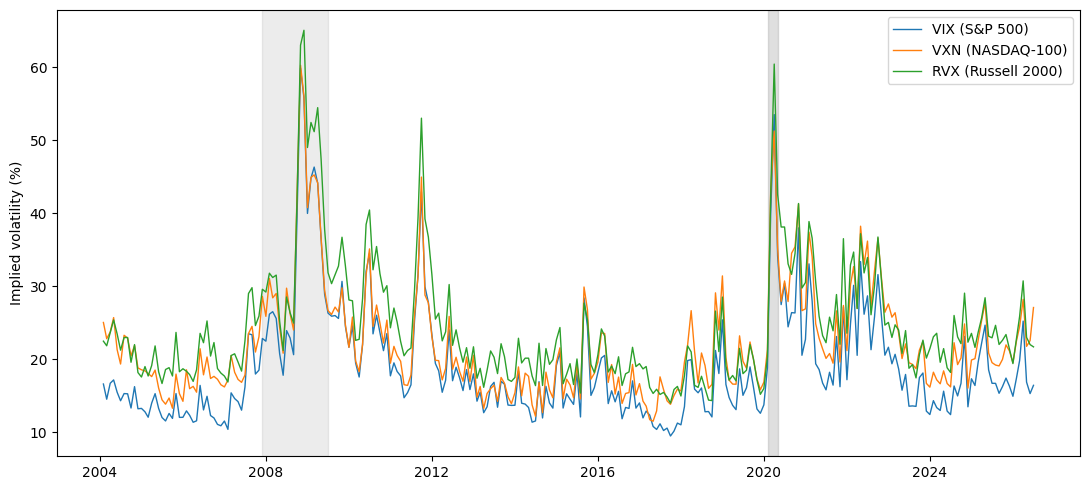

saved


In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11,5))
labels = {'sp500':'VIX (S&P 500)','nasdaq':'VXN (NASDAQ-100)','russell':'RVX (Russell 2000)'}
for k in labels:
    d = data[data['index']==k]
    ax.plot(pd.to_datetime(d['date']), d['iv'], label=labels[k], linewidth=1)
ax.axvspan(pd.Timestamp('2007-12-01'), pd.Timestamp('2009-06-30'), alpha=0.15, color='grey')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-30'), alpha=0.25, color='grey')
ax.set_ylabel('Implied volatility (%)'); ax.legend()
plt.tight_layout(); plt.savefig('figure_4_1_iv_series.png', dpi=200); plt.show()

with pd.ExcelWriter('results_tables.xlsx') as xw:
    for k, t in tables.items():
        t.to_excel(xw, sheet_name=f'Regressions {k}'[:31], index=False)
print('saved')

In [ ]:
"""Extensions: AR(1), correlations, joint tests, alternative crisis definitions,
clustered pooled errors, out-of-sample R2. Runs on merged_monthly_data.csv."""
import pandas as pd, numpy as np
import statsmodels.api as sm

data = pd.read_csv("merged_monthly_data.csv", parse_dates=["date"])
IDX = ["sp500", "nasdaq", "russell"]

# ---- Step 2: AR(1) of IV ----
ar1 = {k: round(data[data["index"]==k].set_index("date")["iv"].autocorr(), 3) for k in IDX}
print("AR1:", ar1)

# ---- Step 3: correlation matrices ----
CORR_COLS = ["exret_fwd","iv","rv","move","gold_ret","oil_ret"]
corrs = {}
for k in IDX:
    corrs[k] = data[data["index"]==k][CORR_COLS].corr().round(2)
    print(f"corr {k}: IV-RV={corrs[k].loc['iv','rv']}, IV-MOVE={corrs[k].loc['iv','move']}, IV-exret={corrs[k].loc['iv','exret_fwd']}")

def fit(d, xvs, cov="hac"):
    dd = d.dropna(subset=["exret_fwd"]+xvs)
    X = sm.add_constant(dd[xvs])
    if cov == "hac":
        return dd, sm.OLS(dd["exret_fwd"], X).fit(cov_type="HAC", cov_kwds={"maxlags":6})
    return dd, X  # for cluster we fit outside

# ---- Step 4: joint tests ----
jt = []
for k in IDX:
    d = data[data["index"]==k]
    _, r2m = fit(d, ["iv","gfc","covid","iv_gfc","iv_covid"])
    f2 = r2m.f_test("iv_gfc = 0, iv_covid = 0")
    _, r3m = fit(d, ["iv","rv"])
    f3 = r3m.f_test("iv = 0, rv = 0")
    jt.append({"index":k, "eq2_F":round(float(f2.fvalue),2), "eq2_p":round(float(f2.pvalue),4),
               "eq3_F":round(float(f3.fvalue),2), "eq3_p":round(float(f3.pvalue),4)})
jt = pd.DataFrame(jt); print(jt.to_string(index=False))

# ---- Step 5a: wide COVID window (Feb-Dec 2020) ----
data["covid_wide"] = ((data["date"]>="2020-02-01") & (data["date"]<="2020-12-31")).astype(int)
data["iv_covid_wide"] = data["iv"]*data["covid_wide"]
wide_rows = []
for k in IDX:
    d = data[data["index"]==k]
    _, r = fit(d, ["iv","gfc","covid_wide","iv_gfc","iv_covid_wide"])
    wide_rows.append({"index":k, **{v: f"{r.params[v]:.5f} ({r.tvalues[v]:.2f})" for v in ["iv","gfc","covid_wide","iv_gfc","iv_covid_wide"]},
                      "N":int(r.nobs), "adjR2":round(r.rsquared_adj,4)})
m4_wide = pd.DataFrame(wide_rows); print(m4_wide.to_string(index=False))

# ---- Step 5b: IV>30 regime ----
data["stress"] = (data["iv"]>30).astype(int)
data["iv_stress"] = data["iv"]*data["stress"]
reg_rows = []
for k in IDX:
    d = data[data["index"]==k]
    nstress = int(d["stress"].sum())
    _, r = fit(d, ["iv","stress","iv_stress"])
    reg_rows.append({"index":k, "stress_months":nstress,
                     **{v: f"{r.params[v]:.5f} ({r.tvalues[v]:.2f})" for v in ["iv","stress","iv_stress"]},
                     "N":int(r.nobs), "adjR2":round(r.rsquared_adj,4)})
m4_regime = pd.DataFrame(reg_rows); print(m4_regime.to_string(index=False))

# ---- Step 6: pooled with clustered SEs ----
p = data.copy()
p["d_nasdaq"] = (p["index"]=="nasdaq").astype(int)
p["d_russell"] = (p["index"]=="russell").astype(int)
XV = ["iv","gfc","covid","iv_gfc","iv_covid","d_nasdaq","d_russell"]
d_est = p.dropna(subset=["exret_fwd"]+XV)
X = sm.add_constant(d_est[XV])
rc = sm.OLS(d_est["exret_fwd"], X).fit(cov_type="cluster", cov_kwds={"groups": d_est["date"]})
pooled = pd.DataFrame({"coef": rc.params.round(5), "t_clustered": rc.tvalues.round(2)})
print(pooled.to_string())
print("pooled N:", int(rc.nobs), "adjR2:", round(rc.rsquared_adj,4))

# ---- Step 7: out-of-sample R2 (Campbell-Thompson) ----
oos_rows = []
for k in IDX:
    d = data[data["index"]==k].sort_values("date").reset_index(drop=True)
    d = d[["date","iv","exret_fwd"]]
    origins = d[(d["date"]>="2013-12-01") & d["exret_fwd"].notna()].index
    se_m, se_b = [], []
    for t in origins:
        info = d.iloc[:t]                      # rows with s <= t-1 (positional)
        info = info.dropna(subset=["exret_fwd"])
        if len(info) < 60: continue
        Xi = sm.add_constant(info[["iv"]])
        f = sm.OLS(info["exret_fwd"], Xi).fit()
        fc = f.params["const"] + f.params["iv"]*d.loc[t,"iv"]
        bench = info["exret_fwd"].mean()
        actual = d.loc[t,"exret_fwd"]
        se_m.append((actual-fc)**2); se_b.append((actual-bench)**2)
    r2 = 1 - sum(se_m)/sum(se_b)
    oos_rows.append({"index":k, "n_forecasts":len(se_m), "OOS_R2":round(r2,4)})
oos = pd.DataFrame(oos_rows); print(oos.to_string(index=False))

# ---- Step 8: export ----
with pd.ExcelWriter("results_tables_v2.xlsx") as xw:
    for k in IDX: corrs[k].to_excel(xw, sheet_name=f"corr_{k}")
    pd.DataFrame([ar1]).to_excel(xw, sheet_name="ar1", index=False)
    jt.to_excel(xw, sheet_name="joint_tests", index=False)
    m4_wide.to_excel(xw, sheet_name="m4_wide", index=False)
    m4_regime.to_excel(xw, sheet_name="m4_regime", index=False)
    pooled.to_excel(xw, sheet_name="pooled_clustered")
    oos.to_excel(xw, sheet_name="oos_r2", index=False)
print("exported results_tables_v2.xlsx")

AR1: {'sp500': np.float64(0.793), 'nasdaq': np.float64(0.787), 'russell': np.float64(0.824)}
corr sp500: IV-RV=0.86, IV-MOVE=0.58, IV-exret=0.04
corr nasdaq: IV-RV=0.84, IV-MOVE=0.58, IV-exret=0.02
corr russell: IV-RV=0.86, IV-MOVE=0.57, IV-exret=0.07
  index  eq2_F  eq2_p  eq3_F  eq3_p
  sp500   4.48 0.0122   0.52 0.5979
 nasdaq   2.66 0.0721   0.63 0.5323
russell   7.36 0.0008   0.79 0.4558
  index             iv              gfc       covid_wide           iv_gfc  iv_covid_wide   N  adjR2
  sp500 0.00109 (2.81) -0.00789 (-0.45) -0.02638 (-1.06) -0.00115 (-1.42) 0.00079 (0.76) 270 0.0410
 nasdaq 0.00059 (1.07) -0.01416 (-0.45)   0.00841 (0.20) -0.00055 (-0.48) 0.00033 (0.26) 270 0.0131
russell 0.00129 (2.86)   0.01101 (0.42) -0.01280 (-0.22) -0.00141 (-1.37) 0.00047 (0.36) 270 0.0192
  index  stress_months             iv           stress        iv_stress   N   adjR2
  sp500             22 0.00059 (1.21)   0.03966 (0.74) -0.00128 (-0.81) 270 -0.0057
 nasdaq             31 0.00089 (1.25